# Explore here

In [8]:
# Your code here
# cargar dataset
import pandas as pd

url = "https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv"
df = pd.read_csv(url, sep=";") # Nota: este dataset suele usar punto y coma

# Visualización inicial
print(df.head())
print(df.info())

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

In [10]:
#analisis exploratorio (EDA) y preprocesamiento de datos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# se convierte la variable objetivo a numérica
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# se separan variables predictoras (X) y objetivo (y)
X = df.drop('y', axis=1)
y = df['y']

# se codifican variables categóricas (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

# se divide en Train y Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
#contruir el modelo de regresión logística
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Crear y entrenar el modelo
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Predicciones
y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7303
           1       0.67      0.43      0.53       935

    accuracy                           0.91      8238
   macro avg       0.80      0.70      0.74      8238
weighted avg       0.90      0.91      0.90      8238



In [13]:
# Optimización, mejorando el Recall para la clase minoritaria (1)
# Optimizamos usando class_weight='balanced'
model_opt = LogisticRegression(class_weight='balanced', max_iter=1000)
model_opt.fit(X_train_scaled, y_train)

# Nuevas predicciones
y_pred_opt = model_opt.predict(X_test_scaled)

# Comparar este reporte con el anterior
print("--- Reporte Optimizado (Balanceado) ---")
print(classification_report(y_test, y_pred_opt))

# hay que checar la matriz para ver los cambios
print("--- Matriz de Confusión ---")
print(confusion_matrix(y_test, y_pred_opt))

--- Reporte Optimizado (Balanceado) ---
              precision    recall  f1-score   support

           0       0.98      0.86      0.92      7303
           1       0.45      0.90      0.60       935

    accuracy                           0.86      8238
   macro avg       0.72      0.88      0.76      8238
weighted avg       0.92      0.86      0.88      8238

--- Matriz de Confusión ---
[[6262 1041]
 [  98  837]]


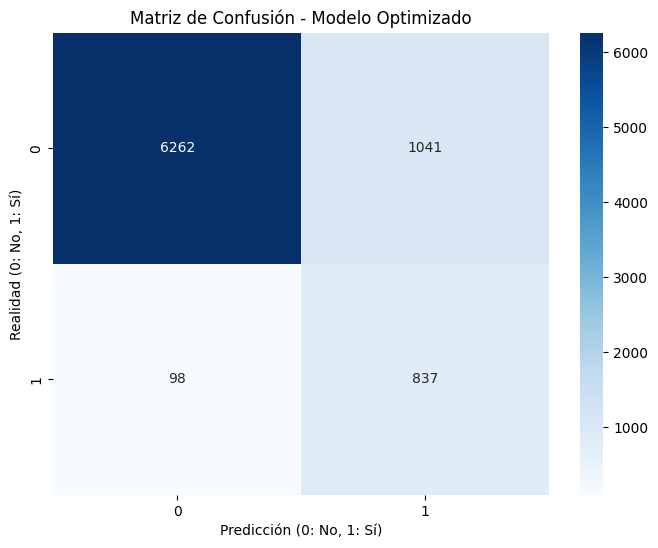

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_opt), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Modelo Optimizado')
plt.xlabel('Predicción (0: No, 1: Sí)')
plt.ylabel('Realidad (0: No, 1: Sí)')
plt.show()